# How much does a mask change size from one z-layer to the next?

A nucleus imaged through z has a cross-section that grows to a mid-plane and
shrinks away from it, and it does that *smoothly* -- consecutive planes are a
few hundred nanometres apart, so the mask on one should look much like the mask
on the next. A mask whose area jumps between adjacent layers is usually not a
cell behaving oddly; it is the segmenter changing its mind.

So the metric here is the **change in mask area between consecutive z-layers**:
for every mask, on every pair of planes it appears on, how many pixels it gained
or lost. By default the sign is discarded, so a number reads as *how far a mask
moved* between two layers; `METRIC = "delta"` puts the direction back.

Two readings, one scan:

* **A -- the whole image.** The average change at each layer step, per model and
  per technique. This is the shape of the average mask through z, and the place
  a technique's per-plane instability shows up as a step that does not belong.
* **B -- one field, split into bands.** Three equally spaced horizontal dividers
  cut a field into four sections, and the same profile is drawn per section. If
  the top of the field behaves differently from the bottom -- a tilted sample, a
  focus or illumination gradient, an uneven coverslip -- that is what separates
  it from a property of the segmentation.

**The volumes are never loaded into memory.** Each multi-page TIFF is opened as
a lazy zarr array whose chunks are the TIFF's own tiles, and `label_plane_areas`
streams over those in chunk-aligned blocks, holding one block plus the labels
present on one plane. The areas are exact counts, not samples.

## Setup

Point `TECHNIQUE_ROOTS` at your own output trees -- one per segmentation
technique, laid out exactly as the z-span notebook expects them:

```
data/segmentations_3d_stitched/<model>/<region>/<fov>/masks.tif
```

`LEVEL_NAMES` names the directory levels **below each technique root**, aligned
to the *trailing* directories, so extra levels above become `level_0`,
`level_1`, .... `MODEL_LEVELS` picks the ones that identify a model and joins
them into a single `variant` label.

`N_SECTIONS = 4` is the three dividers of figure B. It costs nothing to raise:
sections are counted in the same pass, and because a mask crossing a divider is
counted in both bands, summing the bands reproduces the whole-plane area
exactly. Figure A is computed off that sum, so it is not an approximation of
anything.

`SECTION_ASSIGN` decides what a band *means* in figure B:

| | |
|---|---|
| `"whole"` | each mask belongs to the band holding most of it, and the band gets its **whole** area. Answers *where in the field is a mask, and how does that mask behave?* |
| `"split"` | each band gets only the part of the mask inside it. Answers *how does the image change, band by band?*, at the cost of counting boundary-crossing masks as two partial ones. |

`READER` picks the backend. Both stream sub-plane blocks and produce identical
numbers; `"auto"` sends local paths to `tifffile` and anything remote -- an
`s3://` URL, or a path handed an `ObjectStoreRegistry` -- to `virtualizarr`, so
this line does not change when the data moves to a bucket.

In [13]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

from zspan import (
    BLUES,
    CATEGORICAL,
    add_variant_column,
    apply_theme,
    find_mask_files,
    label_plane_areas,
    level_columns,
    local_registry,
    open_mask_volume,
    resolve_reader,
    section_bounds,
    size_change_between_layers,
)
from zspan.plotting import GRID, INK, INK_MUTED, INK_SECONDARY, SURFACE

apply_theme()
pd.set_option("display.width", 160)

# One root per segmentation technique -- point these at your own output trees.
# The keys label every figure; their order is the plotting order.
TECHNIQUE_ROOTS = {
    "3D stitched": Path("data/segmentations_3d_stitched"),
    "true 3D": Path("data/segmentations_3d_true"),
}

PATTERN = "**/masks.tif"                   # glob relative to each technique root
LEVEL_NAMES = ("model", "region", "fov")   # levels below *each* technique root
MODEL_LEVELS = ["model"]                   # joined into a single `variant` label

READER = "auto"     # "auto" | "virtual" | "tifffile"  -- see the table above
MAX_WORKERS = 8     # threads reading volumes; the read size matters far more

# Figure B: 3 equally spaced dividers, so 4 horizontal bands, numbered from the
# top of the image down.
N_SECTIONS = 4
SECTION_ASSIGN = "whole"   # "whole" (mask lives in one band) | "split" (per-band area)

# What "change in size" is measured in, and how the per-layer average is taken.
#
#   abs_delta   pixels, direction discarded: how far a mask moves between
#               layers, which is the comparison between methods.  Nothing
#               cancels, so a difference survives here that `delta` averages
#               away -- growth in the bottom half of a stack against shrinkage
#               in the top half.
#   delta       the same, signed.  Says which way, at the cost of that
#               cancelling; use it to read the shape of a mask through z.
#   pct_change  relative to the mask's area on the lower plane.  Bounded below
#               at -100% and unbounded above, so take its median, or read the
#               mean knowing the tail is one-sided.
METRIC = "abs_delta"    # "abs_delta" | "delta" | "pct_change"
AGGREGATE = "mean"      # "mean" | "median"

# Figure B looks at one part of the data.  Empty picks the least stable volume
# in the scan; otherwise name any level columns, e.g.
#   FOCUS = {"region": "region_A"}                      -- every FOV in a region
#   FOCUS = {"technique": "true 3D", "fov": "fov_01"}   -- one FOV, one technique
FOCUS: dict[str, str | list[str]] = {}
SHOW_PREVIEW = True   # read one mid-stack plane of the focus to draw the bands on

METRIC_UNIT = {
    "abs_delta": "px, either way",
    "delta": "px, signed",
    "pct_change": "% of the lower layer",
}
if METRIC not in METRIC_UNIT:
    raise ValueError(f"METRIC must be one of {sorted(METRIC_UNIT)}, got {METRIC!r}")
if AGGREGATE not in ("mean", "median"):
    raise ValueError(f"AGGREGATE must be 'mean' or 'median', got {AGGREGATE!r}")
if SECTION_ASSIGN not in ("whole", "split"):
    raise ValueError(f"SECTION_ASSIGN must be 'whole' or 'split', got {SECTION_ASSIGN!r}")

# Two lines, and the same string in both figures: a y-axis label long enough to
# outgrow its own axes is how a figure ends up with the title written through it.
Y_LABEL = f"change in mask area per layer step\n({AGGREGATE}, {METRIC_UNIT[METRIC]})"

# Technique is the comparison axis, so it owns the hue channel in figure A --
# one fixed slot each, assigned once, so a colour never changes meaning.  Model
# identity travels on marker shape.  Figure B has neither: its bands are an
# *ordered* quantity, so they get one hue light-to-dark instead.
TECHNIQUE_COLOUR = dict(zip(TECHNIQUE_ROOTS, CATEGORICAL))
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]


# Both figures are the same profile over different slices of the same table, so
# they share the two functions that define it rather than each having a version.
def layer_profile(frame):
    """One value per layer step, every mask in `frame` averaged together.

    Every FOV in the group goes into one number per step -- no per-volume
    weighting, no per-volume lines.  A model that was run over more fields
    therefore contributes more masks to its own line, which is what makes the
    lines directly comparable between techniques.
    """
    return frame.groupby("z_from")[METRIC].agg(AGGREGATE)


def layer_axis(ax, z_steps):
    """Tick each layer step, thinned so a deep stack stays readable."""
    every = max(1, len(z_steps) // 12)
    ax.set_xticks(z_steps[::every], [f"{z}→{z + 1}" for z in z_steps[::every]])
    ax.set_xlabel("layer step")


for name, root in TECHNIQUE_ROOTS.items():
    print(f"{name:14s} {str(root):42s} reader={resolve_reader(READER, root)!r}")

3D stitched    data/segmentations_3d_stitched             reader='tifffile'
true 3D        data/segmentations_3d_true                 reader='tifffile'


## Scan and score

One pass over each technique tree. Every volume is opened lazily and reduced to
a per-label, per-plane, per-band area table, then those are differenced along z
within each mask.

Only *consecutive observations of the same mask* count as a change. A mask's
first plane has nothing to change from, and the plane after its last is not a
shrink to zero but an absence -- counting appearances and disappearances would
add one big positive and one big negative step to every mask and tell you
nothing. Steps that jump a hole in z are dropped for the same reason: a mask
that vanishes and comes back is two objects stitched into one, and the jump
across the hole is not a size change of anything. The count of those is printed
below, because a tree with a lot of them has a stitching problem worth knowing
about before any of this is read.

The last table is the coverage check: a side-by-side comparison is only a
comparison if both techniques ran the same models over the same FOVs.

In [14]:
VOLUME_KEYS = ["technique", "relpath"]   # `relpath` repeats between trees, so both


def scan_areas(name: str, root: Path):
    """Per-label, per-plane, per-band areas for every volume under one root."""
    files = find_mask_files(root, PATTERN)
    backend = resolve_reader(READER, root)
    # Resolve once for the tree: every file under one root routes the same way,
    # and the registry is virtual-only, so it is not built when nothing uses it.
    registry = local_registry(root)[0] if backend == "virtual" else None
    level_columns(files[0].relative_to(root), LEVEL_NAMES)  # fail fast on the layout

    def score(path: Path):
        volume = open_mask_volume(path, registry, reader=backend)
        return volume.shape, label_plane_areas(volume, n_sections=N_SECTIONS)

    frames, rows, done = [], [], 0
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = {pool.submit(score, path): path for path in files}
        for future in as_completed(futures):
            path, done = futures[future], done + 1
            try:
                shape, areas = future.result()
            except Exception as error:  # one bad file must not stop the scan
                print(f"  [{name}] FAILED to read {path}: {error!r}")
                continue
            tags = {
                "technique": name,
                **level_columns(path.relative_to(root), LEVEL_NAMES),
                "relpath": str(path.relative_to(root)),
            }
            frames.append(areas.assign(**tags))
            rows.append({
                **tags, "path": str(path),
                "n_z": shape[0], "ny": shape[1], "nx": shape[2],
                "n_masks": areas["label"].nunique(),
            })
            if done % max(1, len(files) // 2) == 0 or done == len(files):
                print(f"  [{name}] scored {done}/{len(files)} volumes")
    return pd.DataFrame(rows), pd.concat(frames, ignore_index=True)


scanned = [scan_areas(name, root) for name, root in TECHNIQUE_ROOTS.items()]
volumes = add_variant_column(pd.concat([v for v, _ in scanned], ignore_index=True), MODEL_LEVELS)
areas = pd.concat([a for _, a in scanned], ignore_index=True)

META = volumes[[*VOLUME_KEYS, "variant", *LEVEL_NAMES, "n_z", "ny", "nx"]]

# The bands sum back to the whole plane exactly, so figure A costs no second
# scan -- and this is the frame figure B's "whole" assignment measures too.
whole_areas = areas.groupby([*VOLUME_KEYS, "label", "z"], as_index=False)["area"].sum()
changes = (
    size_change_between_layers(whole_areas, group_cols=[*VOLUME_KEYS, "label"])
    .merge(META, on=VOLUME_KEYS)
    .assign(abs_delta=lambda frame: frame["delta"].abs())
)

# Best first: steadiest model, averaged over both techniques, so a model holds
# one legend position in every figure.
model_order = changes.groupby("variant")["abs_delta"].mean().sort_values().index.tolist()
technique_order = [t for t in TECHNIQUE_ROOTS if (volumes["technique"] == t).any()]
z_steps = np.sort(changes["z_from"].unique())   # both figures share this x axis

skipped = size_change_between_layers(
    whole_areas, group_cols=[*VOLUME_KEYS, "label"], adjacent_only=False
).pipe(lambda f: f[f["z_gap"] > 1])
straddling = areas.groupby([*VOLUME_KEYS, "label", "z"]).size()

if volumes["n_z"].nunique() > 1:
    print(f"WARNING: stacks differ in depth {sorted(volumes['n_z'].unique())}; the "
          "layer steps in figure A do not line up across them.")
if volumes[["ny", "nx"]].drop_duplicates().shape[0] > 1:
    print("WARNING: fields differ in size, so a band is a different strip of "
          "tissue in different volumes -- figure B compares within one field.")

coverage = (
    volumes.pivot_table(index="variant", columns="technique", values="relpath", aggfunc="count")
    .reindex(index=model_order, columns=technique_order)
)
if coverage.isna().to_numpy().any() or (coverage.nunique(axis=1) > 1).any():
    print("WARNING: the techniques did not cover the same FOVs -- see the counts below.")

print()
print(f"{len(volumes)} volumes, {volumes['n_masks'].sum():,} masks, "
      f"{len(changes):,} layer steps")
print(f"{len(skipped):,} steps dropped for jumping a hole in z "
      f"({100 * len(skipped) / max(1, len(skipped) + len(changes)):.2f}% of candidate steps)")
print(f"{100 * (straddling > 1).mean():.1f}% of mask-planes cross a band divider "
      f"(SECTION_ASSIGN={SECTION_ASSIGN!r} decides what figure B does with those)")
coverage.fillna(0).astype(int)

  [3D stitched] scored 253/506 volumes
  [3D stitched] scored 506/506 volumes
  [true 3D] scored 184/368 volumes
  [true 3D] scored 368/368 volumes

874 volumes, 770,280 masks, 3,177,407 layer steps
757 steps dropped for jumping a hole in z (0.02% of candidate steps)
5.3% of mask-planes cross a band divider (SECTION_ASSIGN='whole' decides what figure B does with those)


technique,3D stitched,true 3D
variant,,
VePo,264,192
CBDN,242,176


## A. The whole image

One line per model per technique: hue is the technique, marker is the model.
The x axis is the step from one z-layer to the next; the y axis is how much the
average mask's area changed across that step, **direction discarded**. Every FOV
of a model is averaged into its one line.

Discarding the sign is the point. A signed average lets growth in the bottom
half of a stack cancel shrinkage in the top half, which is the shape of a
nucleus rather than a property of the segmentation. What is left compares the
two methods on the only thing that separates them here: how far a mask moves
between adjacent layers.

**Lower is steadier.** A gap that holds across the whole stack is a real
difference between the methods. `stitched` links masks plane by plane, so it can
only be as smooth as its per-plane segmentation; a native 3D run has no
per-plane decision to be inconsistent about, and usually sits below it.

One caveat that does not average away: a mask that merges with its neighbour on
one plane contributes a step the size of a whole cell. Check `p95 |Δ|` in the
table below against the mean before reading a line as typical.

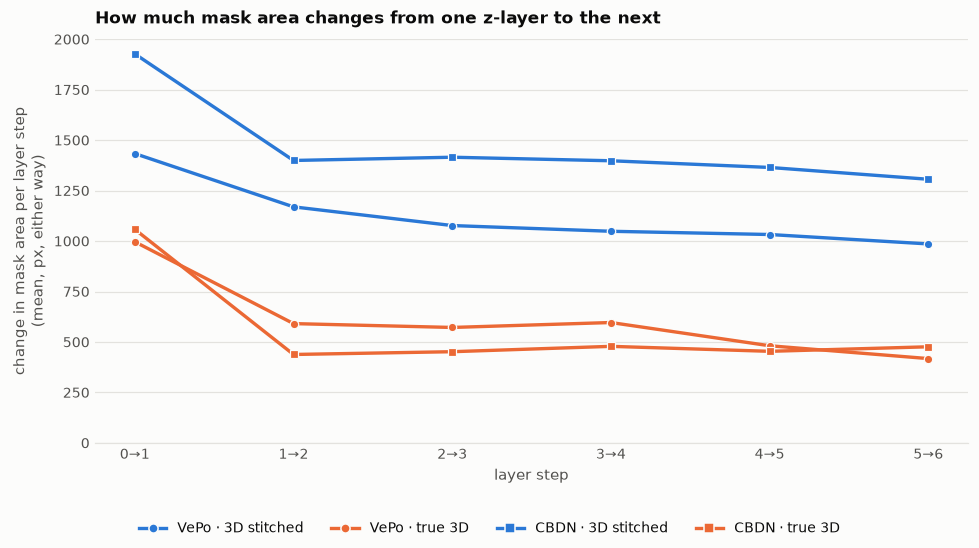

In [15]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))

handles = []
for i, name in enumerate(model_order):
    marker = MARKERS[i % len(MARKERS)]
    for tech in technique_order:
        part = changes[(changes["technique"] == tech) & (changes["variant"] == name)]
        if part.empty:
            continue
        line = layer_profile(part)   # every FOV of this model, averaged together
        ax.plot(line.index, line.to_numpy(), color=TECHNIQUE_COLOUR[tech],
                marker=marker, markersize=5.5, markeredgecolor=SURFACE,
                markeredgewidth=0.8, linewidth=2.2, zorder=3)
        handles.append(Line2D([], [], color=TECHNIQUE_COLOUR[tech], marker=marker,
                              markersize=6, markeredgecolor=SURFACE, linewidth=2.2,
                              label=f"{name} · {tech}"))

layer_axis(ax, z_steps)
ax.set_ylabel(Y_LABEL)
if METRIC == "abs_delta":
    ax.set_ylim(bottom=0)   # a magnitude has a floor, and it is worth showing
else:
    ax.axhline(0, color=INK, linewidth=1.1, zorder=2)
ax.set_title("How much mask area changes from one z-layer to the next",
             pad=10, loc="left")
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
ax.spines["bottom"].set_color(GRID)
ax.spines["left"].set_visible(False)

fig.legend(handles=handles, loc="lower center", ncols=min(4, len(handles)))
fig.tight_layout(rect=(0, 0.08, 1, 1))

### The numbers

Shipped next to the figure on purpose: some palette steps sit below 3:1 contrast
on a light background, so the table is what keeps the comparison readable for
everyone.

`mean |Δ|` is the one to rank on -- unlike the signed mean it does not let a
growing half of the stack cancel a shrinking half, so it reads as *how much a
mask moves between layers at all*. `p95 |Δ|` next to it is the outlier check: if
the mean is a large fraction of the 95th percentile, a handful of merge or split
events are carrying it and the median column is the honest one.

In [16]:
from IPython.display import display

model_table = (
    changes.groupby(["variant", "technique"])
    .agg(
        fovs=("relpath", "nunique"),
        steps=("delta", "size"),
        mean_delta=("delta", "mean"),
        mean_abs_delta=("abs_delta", "mean"),
        p95_abs_delta=("abs_delta", lambda s: s.quantile(0.95)),
        median_pct=("pct_change", "median"),
    )
    .join(volumes.groupby(["variant", "technique"])["n_masks"].sum().rename("masks"))
    .reindex(pd.MultiIndex.from_product([model_order, technique_order],
                                        names=["variant", "technique"]))
    .round(2)
)

paired = model_table["mean_abs_delta"].unstack("technique").reindex(columns=technique_order)
if len(technique_order) == 2:
    first, last = technique_order
    paired[f"Δ ({last} − {first})"] = paired[last] - paired[first]

display(paired.round(2))
model_table[["fovs", "masks", "steps", "mean_delta", "mean_abs_delta",
             "p95_abs_delta", "median_pct"]]

technique,3D stitched,true 3D,Δ (true 3D − 3D stitched)
variant,,,
CBDN,1457.42,526.04,-931.38
VePo,1115.69,589.29,-526.40


fovs   masks    steps  mean_delta  mean_abs_delta  p95_abs_delta  median_pct
variant technique                                                                                
VePo    3D stitched   264  386809  1341073      378.16         1115.69         3568.0        7.74
        true 3D       192  264664  1327609      279.64          589.29         1712.0        8.16
CBDN    3D stitched   242   58162   223091      145.12         1457.42         5440.0        3.07
        true 3D       176   60645   285634      194.85          526.04         1680.0        5.34

## B. One field, four bands

Three equally spaced horizontal dividers, four bands numbered from the top of
the image down. The left panel shows where they cut -- one mid-stack plane of
one field in the focus, read band by band and downsampled for display, so the
preview never holds more than a band at once. The dividers land on the same rows
in every field of that size, so it is a map of the cut, not a portrait of the
data. The right panel is figure A's profile computed within each band, in the
band's colour, and with one panel per technique when the focus spans both.

Bands are a *position*, which is ordered, so they get one hue light-to-dark
rather than a categorical set: pale is the top of the image, dark is the bottom.

**What a real gradient looks like:** the bands separate consistently, in order,
and stay separated across the whole stack. Bands that cross over each other from
step to step are counting noise -- one band of one FOV is a small number of
masks, and the legend gives you the count per band so you can tell which you are
looking at.

The default `METRIC` discards the direction, as in figure A, so these lines read
as *stability* -- how far a mask moves between layers, wherever it sits in the
stack. `METRIC = "delta"` puts the sign back if you want the shape instead, but
expect the bands to tangle in the middle then: a band whose masks turn over
quickly grows hard at the bottom and shrinks hard at the top, and the signed
average cancels in between. The table below carries both columns either way.

A separation that survives is not a segmentation result on its own. It usually
means the *imaging* varied across the field -- tilt, an illumination or focus
gradient, an uneven coverslip -- and the segmenter faithfully reported it. That
is worth knowing either way: it is the difference between a model to fix and a
slide to remount.

In [ ]:
def select_volumes(frame: pd.DataFrame, focus: dict) -> pd.DataFrame:
    """Rows matching every column=value in `focus`; values may be a list."""
    chosen = frame
    for column, value in focus.items():
        if column not in chosen.columns:
            raise KeyError(f"no column {column!r} to focus on; have {list(chosen.columns)}")
        wanted = [value] if isinstance(value, str) else list(value)
        chosen = chosen[chosen[column].isin(wanted)]
    if chosen.empty:
        raise ValueError(f"FOCUS={focus} matched no volumes")
    return chosen


focus = FOCUS
if not focus:
    # Everything sharing the least steady volume's levels except the finest one
    # -- normally its whole region, under both techniques.  One FOV split four
    # ways is a few dozen masks per band, which is not enough to read.
    worst = changes.groupby(VOLUME_KEYS)["abs_delta"].mean().idxmax()
    row = volumes.set_index(VOLUME_KEYS).loc[worst]
    focus = {level: row[level] for level in LEVEL_NAMES[:-1]} or dict(
        zip(VOLUME_KEYS, worst)
    )
    print(f"FOCUS was empty, so this is the least steady volume's region. Pin it "
          f"with\n    FOCUS = {focus!r}\nand narrow it to one field by adding "
          f"{{{LEVEL_NAMES[-1]!r}: ...}}, or point it anywhere else.")

focused = select_volumes(volumes, focus)

# One mask, one band: the band holding most of it, and the band gets the mask's
# whole area.  Ties go to the lower band, which is arbitrary but not random.
if SECTION_ASSIGN == "whole":
    home = (
        areas.groupby([*VOLUME_KEYS, "label", "section"], as_index=False)["area"].sum()
        .sort_values(["area", "section"], kind="stable")
        .drop_duplicates([*VOLUME_KEYS, "label"], keep="last")[[*VOLUME_KEYS, "label", "section"]]
    )
    banded = whole_areas.merge(home, on=[*VOLUME_KEYS, "label"])
else:
    banded = areas[[*VOLUME_KEYS, "label", "section", "z", "area"]]

section_changes = (
    size_change_between_layers(banded, group_cols=[*VOLUME_KEYS, "label", "section"])
    .merge(focused[VOLUME_KEYS], on=VOLUME_KEYS)
    .assign(abs_delta=lambda frame: frame["delta"].abs())
)

focus_techniques = [t for t in technique_order if (focused["technique"] == t).any()]
if len(focused[["ny", "nx"]].drop_duplicates()) > 1:
    print("WARNING: the focused volumes are not all the same size, so band 1 of "
          "one is not band 1 of another; the bands below are the first one's.")
ny, nx = int(focused["ny"].iloc[0]), int(focused["nx"].iloc[0])
bounds = section_bounds(ny, N_SECTIONS)
band_colour = BLUES(np.linspace(0.38, 1.0, N_SECTIONS))

print(f"\n{len(focused)} volume(s) in focus, "
      f"{focused['n_masks'].sum():,} masks, {len(section_changes):,} layer steps")
print(f"bands of a {ny}x{nx} field: " + ", ".join(
    f"{i + 1}=rows {a}–{b}" for i, (a, b) in enumerate(bounds)))
focused[[*VOLUME_KEYS, "variant", "n_masks"]].reset_index(drop=True)

In [ ]:
def band_preview(path: str, bounds, max_px: int = 420):
    """A downsampled occupancy map of one mid-stack plane, read band by band.

    Never more than one band is resident: the point of the figure is where
    things sit in the field, which survives any amount of downsampling.
    """
    volume = open_mask_volume(path, reader=READER)
    nz, ny, _ = volume.shape
    step = max(1, ny // max_px)
    z = nz // 2
    strips = [
        np.asarray(volume.read_plane(z, slice(y0, y1)))[::step, ::step] != 0
        for y0, y1 in bounds
    ]
    return np.concatenate(strips, axis=0), z


fig, axes = plt.subplots(
    1, 1 + len(focus_techniques), sharey=False,
    figsize=(3.4 + 4.6 * len(focus_techniques), 5.2),
    gridspec_kw={"width_ratios": [1.0] + [1.7] * len(focus_techniques)},
)
axes = np.atleast_1d(axes)
field, panels = axes[0], axes[1:]
field_title = "where the bands cut"

if SHOW_PREVIEW:
    try:
        preview, preview_z = band_preview(focused["path"].iloc[0], bounds)
        field.imshow(preview, cmap=ListedColormap([SURFACE, INK_MUTED]),
                     extent=(0, nx, ny, 0), interpolation="nearest", zorder=1)
        # One representative field: the cut is the same rows in all of them, so
        # this says where the bands are, not what the average field looks like.
        field_title = (f"plane {preview_z} of "
                       f"{Path(focused['relpath'].iloc[0]).parent}")
    except Exception as error:  # a preview is a nicety; the bands are the figure
        print(f"NOTE: could not read a preview plane ({error!r}); showing the bands only.")

field.set_title(field_title, pad=8, loc="left", fontsize=9.5,
                fontweight="normal", color=INK_SECONDARY)

field.set_xlim(0, nx)
field.set_ylim(ny, 0)
for i, (y0, y1) in enumerate(bounds):
    field.axhspan(y0, y1, color=band_colour[i], alpha=0.30, zorder=2, linewidth=0)
    if i:  # the dividers themselves -- the interior boundaries only
        field.axhline(y0, color=INK, linewidth=1.2, zorder=3)
    field.text(nx * 0.03, (y0 + y1) / 2, str(i + 1), va="center", ha="left",
               fontsize=11, fontweight="bold", color=INK, zorder=4)
field.set_xticks([])
field.set_yticks([b[0] for b in bounds] + [ny])
field.tick_params(length=0)
for side in ("left", "bottom"):
    field.spines[side].set_color(GRID)

handles = []
for ax, tech in zip(panels, focus_techniques):
    part = section_changes[section_changes["technique"] == tech]
    if METRIC != "abs_delta":
        ax.axhline(0, color=INK, linewidth=1.1, zorder=3)
    for i in range(N_SECTIONS):
        band = part[part["section"] == i]
        if band.empty:
            continue
        line = layer_profile(band)
        ax.plot(line.index, line.to_numpy(), color=band_colour[i], marker="o",
                markersize=4.5, markeredgecolor=SURFACE, markeredgewidth=0.8,
                linewidth=1.9, zorder=4)
        if ax is panels[0]:
            handles.append(Line2D(
                [], [], color=band_colour[i], marker="o", markersize=5,
                markeredgecolor=SURFACE, linewidth=1.9,
                label=f"{i + 1} · rows {bounds[i][0]}–{bounds[i][1]} · n={len(band):,}",
            ))
    layer_axis(ax, z_steps)
    ax.set_title(tech, pad=8, loc="left", fontsize=10, fontweight="normal",
                 color=INK_SECONDARY)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    ax.spines["bottom"].set_color(GRID)
    ax.spines["left"].set_visible(False)

panels[0].set_ylabel(Y_LABEL)
if METRIC == "abs_delta":
    for ax in panels:
        ax.set_ylim(bottom=0)
if len(panels) > 1:  # one scale, or the panels are not comparable
    low = min(ax.get_ylim()[0] for ax in panels)
    high = max(ax.get_ylim()[1] for ax in panels)
    for ax in panels:
        ax.set_ylim(low, high)

fig.suptitle(
    f"Change in mask size by band  ({N_SECTIONS} bands, "
    f"SECTION_ASSIGN={SECTION_ASSIGN!r})",
    x=0.008, ha="left", fontsize=11, fontweight="bold", color=INK,
)
fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.012, 0.005),
           ncols=min(4, len(handles)), title="band · rows · layer steps")
# Not tight_layout: the field panel holds a fixed aspect ratio, which tight
# layout cannot solve for, and quietly warns about rather than fixing.
fig.subplots_adjust(left=0.055, right=0.985, top=0.86, bottom=0.24, wspace=0.26)

### Per-band numbers

The same caveat as figure A, sharper: one band of one field is a small number of
masks. `steps` is what each row rests on -- a band with a few dozen is a hint,
not a measurement, and the fix is more FOVs in the focus (point `FOCUS` at a
region rather than a single volume), not a smoother line.

In [ ]:
band_table = (
    section_changes.assign(
        # label ids restart in every volume, so a plain nunique would merge the
        # first mask of every FOV in the focus into one
        mask_uid=section_changes["relpath"] + "#" + section_changes["label"].astype(str),
    )
    .groupby(["technique", "section"])
    .agg(
        masks=("mask_uid", "nunique"),
        steps=("delta", "size"),
        mean_delta=("delta", "mean"),
        mean_abs_delta=("abs_delta", "mean"),
        median_pct=("pct_change", "median"),
    )
    .round(2)
)
band_table.insert(0, "rows", [f"{bounds[s][0]}–{bounds[s][1]}"
                              for _, s in band_table.index])
band_table.rename_axis(index={"section": "band"})

## What this does not tell you

* **A step is not a mask.** Every number here is an average over layer steps, so
  a fat mask spanning nine planes contributes eight steps and a thin one
  contributes one. That is the right weighting for *how does a mask change
  between layers*, and the wrong one for *how do masks compare* -- for the
  latter, weight per mask first, or use the z-span notebook, which counts masks.
* **Merges and splits are size changes.** A mask that swallows its neighbour on
  one plane produces a single step the size of a cell. That is real and worth
  seeing, but it is not the same phenomenon as a mask drifting a few percent, so
  check `p95 |Δ|` against the mean before reading the mean as typical.
* **Pixels are not volume.** These are pixel counts on a plane. If your z step
  differs between runs, the same physical nucleus produces different per-layer
  changes, and comparing the two says more about the microscope than the model.
* **Bands are horizontal only.** Three dividers cut the field top to bottom. A
  gradient running left to right is invisible here; the same scan supports
  vertical bands by transposing the planes on read, but nothing above does that.

## Hand-off to napari

`to_xarray()` returns a lazy dask-backed `DataArray`, so napari pulls only the
planes it displays:

```python
import napari

viewer = napari.Viewer()
volume = open_mask_volume(focused["path"].iloc[0], reader=READER)
viewer.add_labels(volume.to_xarray().data, name=focused["relpath"].iloc[0])
```

The band dividers are rows `[b[0] for b in bounds]` in the same coordinates, so
a `Shapes` layer of horizontal lines at those rows puts figure B's sections on
the image itself.